# Simplex method benchmarks

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import sys
# sys.path.append('.')
# sys.path.append('./DynaMix/')

plt.rcParams["font.family"] = "Helvetica"

# Lyapunov exponent calculation

In [8]:
import sys
## add the path to the project
sys.path.append('..')

from models.parrot import SimplexForecaster, context_parroting_forecast


In [43]:


# ?max_lyapunov_exponent_rosenstein
import sys
## add the path to the project
sys.path.append('..')

from models.parrot import SimplexForecaster


In [65]:
import torch
from chronos import BaseChronosPipeline, ChronosPipeline, ChronosBoltPipeline

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",  # use "amazon/chronos-bolt-small" for the corresponding Chronos-Bolt model
    #"amazon/chronos-bolt-base",
    #device_map="cuda",  # use "cpu" for CPU inference
    device_map="mps",
    torch_dtype=torch.bfloat16,
)

In [34]:
import sys
# sys.path.append('.')
sys.path.append('./DynaMix/')

import torch
# from src.model.dynamix import DynaMix
from src.model.forecaster import DynaMixForecaster
# from src.metrics.metrics import geometrical_misalignment, temporal_misalignment, MASE
# from src.utilities.plotting_eval import plot_3D_attractor, plot_2D_attractor, plot_TS_forecast
from src.utilities.utilities import load_hf_model

# Load the pre-trained model
model = load_hf_model("dynamix-3d-alrnn-v1.0")
model.eval() # Set model to evaluation mode
forecaster = DynaMixForecaster(model) # Initialize the forecaster

/Users/william/program_repos/parroting/benchmark/DynaMix/src/model/dynamix.py:95: RuntimeWarning: divide by zero encountered in matmul
  K = R.T @ R / M + np.eye(M)
/Users/william/program_repos/parroting/benchmark/DynaMix/src/model/dynamix.py:95: RuntimeWarning: overflow encountered in matmul
  K = R.T @ R / M + np.eye(M)
/Users/william/program_repos/parroting/benchmark/DynaMix/src/model/dynamix.py:95: RuntimeWarning: invalid value encountered in matmul
  K = R.T @ R / M + np.eye(M)


In [ ]:
import glob
from dysts.analysis import max_lyapunov_exponent_rosenstein, max_lyapunov_exponent_rosenstein_multivariate, gp_dim
from dysts.metrics import estimate_kl_divergence


results_path = "../analysis/Chronos_statistics/"
CHECK_EXISTING = False


forecast_length = 300
context_lengths = np.unique(np.logspace(np.log10(forecast_length), np.log10(4000), 10).astype(int))



if CHECK_EXISTING:
    all_lyap = np.load(results_path + '/all_lyap_vary_context.npy', allow_pickle=True).tolist()
    all_cdim = np.load(results_path + '/all_cdim_vary_context.npy', allow_pickle=True).tolist()
    all_kl_dist = np.load(results_path + '/all_kl_dist_vary_context.npy', allow_pickle=True).tolist()
else:
    all_lyap = list()
    all_cdim = list()
    all_kl_dist = list()

for trajectory in sorted(glob.glob("../data/long_trajectories/*.npy")):
    equation_name = trajectory.split("/")[-1].split(".")[0]
    print(equation_name, flush=True)
    # if equation_name in found_systems:
    #     print(f"Skipping {equation_name} because it's already in the found_systems list", flush=True)
    #     continue
    
    traj = np.load(trajectory, allow_pickle=True)
    traj = (traj - np.mean(traj, axis=0)) / np.std(traj, axis=0)

    try:
        
        all_cdim_inner = []
        all_kl_dist_inner = []
        all_lyap_inner = []
        for context_length in context_lengths:
            traj_context = traj[:context_length, :]
            traj_true = traj[context_length:context_length+forecast_length, :]



            # traj_pred = list()
            # for mode in range(traj_context.shape[1]):
            #     traj_pred_mode = context_parroting_forecast(traj_context[:, mode], forecast_total_length=forecast_length)[2]
            #     traj_pred.append(traj_pred_mode)
            # traj_pred = np.array(traj_pred).T

            # traj_pred = list()
            # for mode in range(traj_context.shape[1]):
            #     model = SimplexForecaster()
            #     model.fit(traj_context[:, mode])
            #     traj_pred_mode = model.forecast(forecast_length)
            #     traj_pred.append(traj_pred_mode)
            # traj_pred = np.array(traj_pred).T


            traj_pred = list()
            for mode in range(traj_context.shape[1]):
                forecast = pipeline.predict(
                    inputs=torch.tensor(traj_context[:, mode]),
                    prediction_length=forecast_length,
                    num_samples=20,
                    limit_prediction_length=False,
                    )
                traj_pred_mode = np.mean(forecast[0, :, :].detach().numpy(), axis=0)
                traj_pred.append(traj_pred_mode)
            traj_pred = np.array(traj_pred).T


            # context_traj_tensor  = torch.tensor(traj_context)
            # with torch.no_grad(): 
            #     reconstruction = forecaster.forecast(
            #         context=context_traj_tensor,
            #         horizon=forecast_length, # Match the horizon of the ground truth
            #         standardize=True,
            #     )
            # traj_pred = reconstruction.detach().numpy()

            
            kl_dist = estimate_kl_divergence(traj_true, traj_pred)
            if np.isinf(kl_dist): kl_dist = np.nan
            
            
            cdim_true = gp_dim(traj_true)
            cdim_pred = gp_dim(traj_pred)
            cdim = np.array([cdim_pred, cdim_true])

            lyap_true = max_lyapunov_exponent_rosenstein(traj_true)
            if np.isinf(lyap_true): lyap_true = 0
            lyap_pred = max_lyapunov_exponent_rosenstein(traj_pred)
            if np.isinf(lyap_pred): lyap_pred = 0
            lyap = np.array([lyap_pred, lyap_true])


            all_cdim_inner.append(cdim)
            all_kl_dist_inner.append(kl_dist)
            all_lyap_inner.append(lyap)

        all_cdim.append(all_cdim_inner)
        all_kl_dist.append(all_kl_dist_inner)
        all_lyap.append(all_lyap_inner)

        # np.array(all_cdim).dump(results_path + '/all_cdim_vary_context.npy')
        # np.array(all_kl_dist).dump(results_path + '/all_kl_dist_vary_context.npy')
        # np.array(all_lyap).dump(results_path + '/all_lyap_vary_context.npy')


    except Exception as e:
        print(e)
        print(f"Skipping {equation_name}", flush=True)
        continue


In [67]:
results_path = "../analysis/Chronos_statistics/"
np.array(all_cdim).dump(results_path + '/all_cdim_vary_context.npy')
np.array(all_kl_dist).dump(results_path + '/all_kl_dist_vary_context.npy')
np.array(all_lyap).dump(results_path + '/all_lyap_vary_context.npy')

Text(0, 0.5, 'KL Divergence')

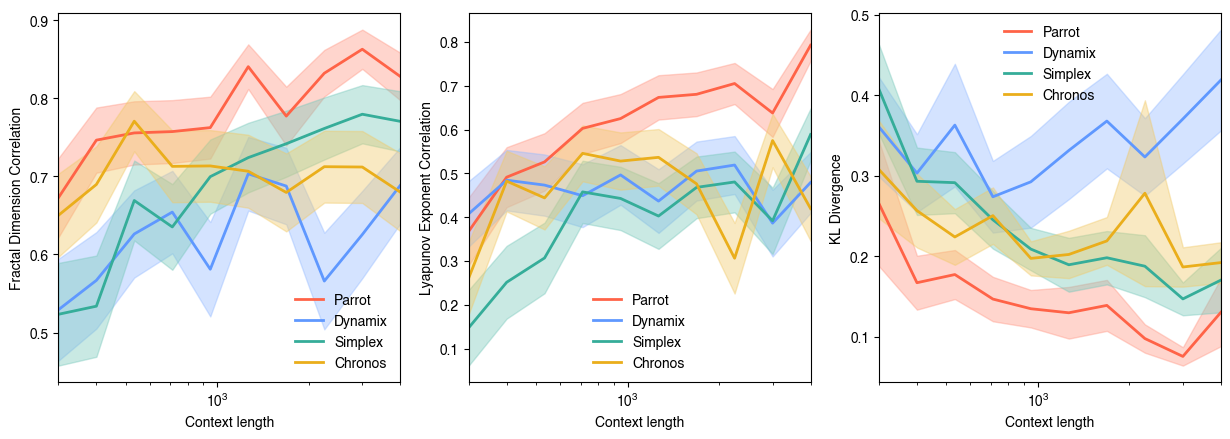

In [209]:
from scipy.stats import pearsonr, spearmanr

model_names = ["parrot", "dynamix", "simplex", "Chronos"]
# model_names = ["parrot", "dynamix",  "simplex"]

import degas as dg
colors = [dg.red, dg.blue, dg.turquoise, dg.orange][:len(model_names)]


context_lengths = np.unique(np.logspace(np.log10(forecast_length), np.log10(4000), 10).astype(int))

from scipy.stats import norm
def err_from_corr(corr, pvalue):
    z_obs = np.arctanh(corr)
    z_stat = abs(norm.ppf(pvalue / 2))
    sd_z = abs(z_obs) / z_stat if z_stat != 0 else np.nan
    sd_r = sd_z * (1 - corr**2)
    return sd_r

plt.figure(figsize=(15, 4.8))

plt.subplot(1, 3, 1)
for model_name, color in zip(model_names, colors):
    results_path = f"../analysis/{model_name}_statistics/"
    all_cdim = np.load(results_path + '/all_cdim_vary_context.npy', allow_pickle=True)

    all_cdim = np.array(all_cdim)
    all_cdim_transposed = all_cdim.transpose(1, 0, 2)
    
    corrs = [spearmanr(cdim_pair[:, 0], cdim_pair[:, 1])[0] for cdim_pair in all_cdim_transposed]
    corr_errs = [err_from_corr(corr, spearmanr(cdim_pair[:, 0], cdim_pair[:, 1])[1]) for corr, cdim_pair in zip(corrs, all_cdim_transposed)]
    # plt.semilogx(
    #     context_lengths, [spearmanr(lyap_pair[:, 0], lyap_pair[:, 1])[0] for lyap_pair in all_lyap_transposed], label=model_name.capitalize()
    # )
    corrs = [spearmanr(cdim_pair[:, 0], cdim_pair[:, 1])[0] for cdim_pair in all_cdim_transposed]
    corr_errs = [err_from_corr(corr, spearmanr(cdim_pair[:, 0], cdim_pair[:, 1])[1]) for corr, cdim_pair in zip(corrs, all_cdim_transposed)]
    plt.semilogx()
    dg.plot_err(np.array(corrs), np.array(corr_errs), x=context_lengths, label=model_name.capitalize(), color=color, linewidth=2)

plt.xlim(context_lengths[0], context_lengths[-1])
plt.legend(frameon=False)
plt.xlabel("Context length")
plt.ylabel("Fractal Dimension Correlation")


plt.subplot(1, 3, 2)
for model_name, color in zip(model_names, colors):
    results_path = f"../analysis/{model_name}_statistics/"
    all_lyap = np.load(results_path + '/all_lyap_vary_context.npy', allow_pickle=True)

    all_lyap = np.array(all_lyap)
    all_lyap_transposed = all_lyap.transpose(1, 0, 2)
    ## Capitalize the first letter of the model name
    corrs = [spearmanr(lyap_pair[:, 0], lyap_pair[:, 1])[0] for lyap_pair in all_lyap_transposed]
    corr_errs = [err_from_corr(corr, spearmanr(lyap_pair[:, 0], lyap_pair[:, 1])[1]) for corr, lyap_pair in zip(corrs, all_lyap_transposed)]
    # plt.semilogx(
    #     context_lengths, [spearmanr(lyap_pair[:, 0], lyap_pair[:, 1])[0] for lyap_pair in all_lyap_transposed], label=model_name.capitalize()
    # )
    plt.semilogx()
    dg.plot_err(np.array(corrs), np.array(corr_errs), x=context_lengths, label=model_name.capitalize(), color=color, linewidth=2)

plt.xlim(context_lengths[0], context_lengths[-1])
plt.legend(frameon=False)
plt.xlabel("Context length")
plt.ylabel("Lyapunov Exponent Correlation")


plt.subplot(1, 3, 3)
for model_name, color in zip(model_names, colors):
    results_path = f"../analysis/{model_name}_statistics/"
    all_kl_dist = np.load(results_path + '/all_kl_dist_vary_context.npy', allow_pickle=True)

    all_kl_dist = np.array(all_kl_dist)

    ## Capitalize the first letter of the model name
    # plt.semilogx(
    #     context_lengths, np.mean(all_kl_dist, axis=0), label=model_name.capitalize()
    # )
    plt.semilogx()
    dg.plot_err(
        np.mean(all_kl_dist, axis=0), np.std(all_kl_dist, axis=0) / np.sqrt(len(all_kl_dist)),
         x=context_lengths, label=model_name.capitalize(), color=color, linewidth=2
    )
plt.xlim(context_lengths[0], context_lengths[-1])
plt.legend(frameon=False)
plt.xlabel("Context length")
plt.ylabel("KL Divergence")


# dg.better_savefig("../analysis/vary_context.pdf", dpi=300, transparent=True)


# Schematics

In [22]:
from dysts.flows import Lorenz

# eq = Lorenz()
# eq.ic += 0.05
# traj = eq.make_trajectory(512 + 500 + 500, standardize=True)[500:]
# traj_context = traj[:512, :]
# traj_true = traj[512:, :]



eq = Lorenz()
eq.ic += 0.05
traj = eq.make_trajectory(512 + 500 + 500, standardize=True)[500:]
traj_context = traj[:512, :]
traj_true = traj[512:, :]





In [153]:
import torch
from chronos import BaseChronosPipeline, ChronosPipeline, ChronosBoltPipeline

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",  # use "amazon/chronos-bolt-small" for the corresponding Chronos-Bolt model
    #"amazon/chronos-bolt-base",
    #device_map="cuda",  # use "cpu" for CPU inference
    device_map="mps",
    torch_dtype=torch.bfloat16,
)


traj_pred = list()
for mode in range(traj_context.shape[1]):
    forecast = pipeline.predict(
        inputs=torch.tensor(traj_context[:, mode]),
        prediction_length=len(traj_true),
        num_samples=20,
        limit_prediction_length=False,
        )
    traj_pred_mode = np.mean(forecast[0, :, :].detach().numpy(), axis=0)
    traj_pred.append(traj_pred_mode)
traj_pred = np.array(traj_pred).T


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


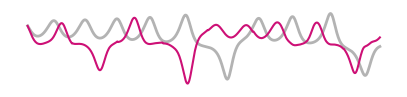

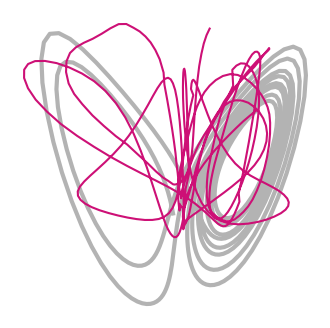

In [141]:
import degas as dg
plt.figure(figsize=(5, 1))
plt.plot(traj_true[:,0], label="True", color=0.7*np.ones(3), linewidth=2)
plt.plot(traj_pred[:,0], label="Pred", color=dg.magenta)
dg.vanish_axes()
dg.better_savefig("../analysis/fig_resources/chronos1_univariate.pdf", dpi=300, transparent=True)


plt.figure(figsize=(4, 4))
plt.plot(traj_true[:,0], traj_true[:,2], color=0.7*np.ones(3), linewidth=3)
plt.plot(traj_pred[:,0], traj_pred[:,2], color=dg.magenta)
dg.vanish_axes()
dg.better_savefig("../analysis/fig_resources/chronos1_multivariate.pdf", dpi=300, transparent=True)

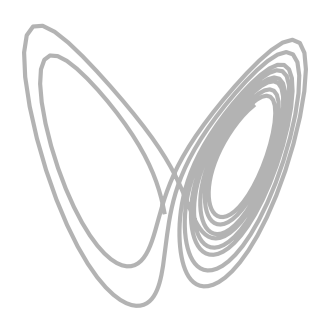

In [ ]:

# plt.figure(figsize=(4, 4))
# plt.plot(traj_true[:,0], traj_true[:,2], color=0.7*np.ones(3), linewidth=3)
# # plt.plot(traj_pred[:,0], traj_pred[:,2], color=dg.magenta)
# plt.xlim(1.1*np.min(traj_true[:,0]), 1.1*np.max(traj_true[:,0]))
# plt.ylim(1.1*np.min(traj_true[:,2]), 1.1*np.max(traj_true[:,2]))
# dg.vanish_axes()

In [188]:
for i in range(1, traj_context.shape[0]):
    traj_context_subset = traj_context[-i:, :].copy()
    traj_pred = list()
    for mode in range(traj_context.shape[1]):
        forecast = pipeline.predict(
            inputs=torch.tensor(traj_context_subset[:, mode]),
            prediction_length=len(traj_true),
            num_samples=20,
            limit_prediction_length=False,
        )
        traj_pred_mode = np.mean(forecast[0, :, :].detach().numpy(), axis=0)
        traj_pred.append(traj_pred_mode)
    traj_pred = np.array(traj_pred).T

    plt.figure(figsize=(4, 4))
    plt.plot(traj_true[:,0], traj_true[:,2], color=0.7*np.ones(3), linewidth=3)
    plt.plot(traj_pred[:,0], traj_pred[:,2], color=dg.magenta)
    plt.xlim(1.1*np.min(traj_true[:,0]), 1.1*np.max(traj_true[:,0]))
    plt.ylim(1.1*np.min(traj_true[:,2]), 1.1*np.max(traj_true[:,2]))
    dg.vanish_axes()
    dg.better_savefig(f"../analysis/fig_resources/frames/chronos1_multivariate_{str(i).zfill(4)}.png", dpi=300, transparent=True)
    
    plt.close()

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of l

In [23]:
from chronos import Chronos2Pipeline

pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="mps")


In [24]:
forecast = pipeline.predict(
    inputs=torch.tensor(traj_context.T[None, ...]),
    prediction_length=len(traj_true),
    # num_samples=20,
    # limit_prediction_length=False,
    )[0]
traj_pred = np.median(forecast.detach().numpy(), axis=1).T

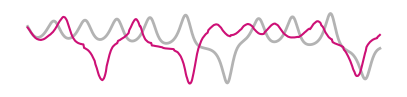

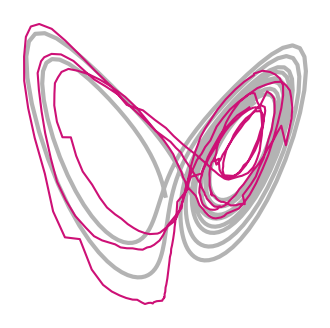

In [25]:
import degas as dg
plt.figure(figsize=(5, 1))
plt.plot(traj_true[:,0], label="True", color=0.7*np.ones(3), linewidth=2)
plt.plot(traj_pred[:,0], label="Pred", color=dg.magenta)
dg.vanish_axes()
# dg.better_savefig("../analysis/fig_resources/chronos2_univariate.pdf", dpi=300, transparent=True)


plt.figure(figsize=(4, 4))
plt.plot(traj_true[:,0], traj_true[:,2], color=0.7*np.ones(3), linewidth=3)
plt.plot(traj_pred[:,0], traj_pred[:,2], color=dg.magenta)
dg.vanish_axes()
# dg.better_savefig("../analysis/fig_resources/chronos2_multivariate.pdf", dpi=300, transparent=True)

In [ ]:
all_chronos2_pred = list()
for i in range(1, traj_context.shape[0]):
    if i % 50 == 0:
        print(f"Processing {i} / {traj_context.shape[0]}")
    traj_context_subset = traj_context[-i:, :].copy()
    forecast = pipeline.predict(
        inputs=torch.tensor(traj_context_subset.T[None, ...]),
        prediction_length=len(traj_true),
        # num_samples=20,
        # limit_prediction_length=False,
        )[0]
    traj_pred = np.median(forecast.detach().numpy(), axis=1).T
    all_chronos2_pred.append(traj_pred)
all_chronos2_pred = np.array(all_chronos2_pred)
all_chronos2_pred.dump("../analysis/fig_resources/all_chronos2_pred.npy")



Processing 50 / 512
Processing 100 / 512
Processing 150 / 512
Processing 200 / 512
Processing 250 / 512
Processing 300 / 512
Processing 350 / 512
Processing 400 / 512
Processing 450 / 512
Processing 500 / 512


In [10]:
for i, traj_pred in enumerate(all_chronos2_pred):
    plt.figure(figsize=(4, 4))
    plt.plot(traj_true[:,0], traj_true[:,2], color=0.7*np.ones(3), linewidth=3)
    plt.plot(traj_pred[:,0], traj_pred[:,2], color=dg.magenta)
    plt.xlim(1.1*np.min(traj_true[:,0]), 1.1*np.max(traj_true[:,0]))
    plt.ylim(1.1*np.min(traj_true[:,2]), 1.1*np.max(traj_true[:,2]))
    dg.vanish_axes()
    dg.better_savefig(f"../analysis/fig_resources/chronos2/chronos2_multivariate_{str(i).zfill(4)}.png", dpi=300, transparent=True)
    plt.close()

In [135]:
traj_pred = list()
for mode in range(traj_context.shape[1]):
    forecast = pipeline.predict(
        inputs=torch.tensor(traj_context[:, mode][:, None].T[None, ...]),
        prediction_length=len(traj_true),
        
        # num_samples=20,
        # limit_prediction_length=False,
        )[0]
    traj_pred_mode = np.median(forecast.detach().numpy(), axis=1).T
    traj_pred.append(traj_pred_mode)
traj_pred = np.array(traj_pred).T.squeeze()

/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


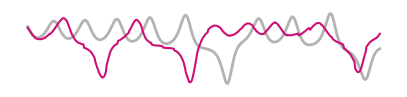

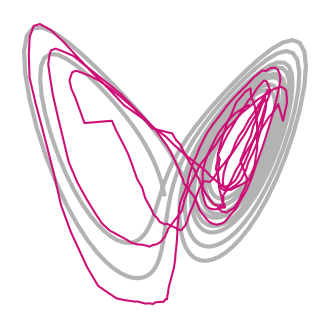

In [136]:
import degas as dg
plt.figure(figsize=(5, 1))
plt.plot(traj_true[:,0], label="True", color=0.7*np.ones(3), linewidth=2)
plt.plot(traj_pred[:,0], label="Pred", color=dg.magenta)
dg.vanish_axes()
# dg.better_savefig("../analysis/fig_resources/chronos2_univariate.pdf", dpi=300, transparent=True)


plt.figure(figsize=(4, 4))
plt.plot(traj_true[:,0], traj_true[:,2], color=0.7*np.ones(3), linewidth=3)
plt.plot(traj_pred[:,0], traj_pred[:,2], color=dg.magenta)
dg.vanish_axes()
# dg.better_savefig("../analysis/fig_resources/chronos2_multivariate.pdf", dpi=300, transparent=True)

In [26]:
import numpy as np
import torch
from einops import rearrange
from uni2ts.model.moirai2 import Moirai2Module, Moirai2Forecast

context_length = 512
forecast_length = 300
BSZ = 32

def moirai2_forecast(y: np.ndarray, forecast_horizon: int, ctx: int | None = None) -> np.ndarray:
    """
    Args:
        y (np.ndarray): 1D array of past values.
        forecast_horizon (int): Number of steps to predict.
        ctx (int | None): Optional context length to use (defaults to min(len(y), 1680)).

    Returns
        (np.ndarray): Median forecast of shape (forecast_horizon,).
    """
    ctx = int(ctx) if ctx is not None else min(len(y), 1680)
    model = Moirai2Forecast(
        module=Moirai2Module.from_pretrained("Salesforce/moirai-2.0-R-small"),
        prediction_length=forecast_horizon,
        context_length=ctx,
        target_dim=1,
        feat_dynamic_real_dim=0,
        past_feat_dynamic_real_dim=0,
    )
    x = rearrange(torch.as_tensor(y[-ctx:], dtype=torch.float32), "t -> 1 t 1")
    with torch.no_grad():
        samples_list = model.predict(x)            # list-like; samples_list[0] -> (num_samples, H)
    return np.median(np.asarray(samples_list[0]), axis=0)

# y_pred = moirai2_forecast(traj_context, forecast_length)
traj_pred = list()
for dim_ind in range(traj_context.shape[1]):
    traj_pred_dim = moirai2_forecast(traj_context[:, dim_ind], len(traj_true))
    traj_pred.append(traj_pred_dim)
traj_pred = np.array(traj_pred).T


/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


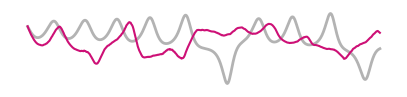

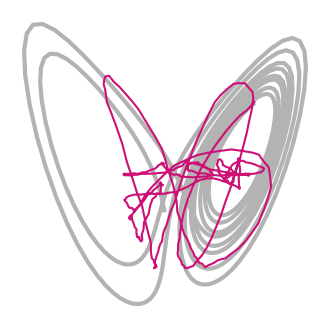

In [27]:
import degas as dg
plt.figure(figsize=(5, 1))
plt.plot(traj_true[:,0], label="True", color=0.7*np.ones(3), linewidth=2)
plt.plot(traj_pred[:,0], label="Pred", color=dg.magenta)
dg.vanish_axes()
# dg.better_savefig("../analysis/fig_resources/moirai2_univariate.pdf", dpi=300, transparent=True)


plt.figure(figsize=(4, 4))
plt.plot(traj_true[:,0], traj_true[:,2], color=0.7*np.ones(3), linewidth=3)
plt.plot(traj_pred[:,0], traj_pred[:,2], color=dg.magenta)
dg.vanish_axes()
# dg.better_savefig("../analysis/fig_resources/moirai2_multivariate.pdf", dpi=300, transparent=True)

In [30]:
all_moirai2_pred = list()
for i in range(1, traj_context.shape[0]):
    if i % 50 == 0:
        print(f"Processing {i} / {traj_context.shape[0]}")
    traj_context_subset = traj_context[-i:, :].copy()
    traj_pred = list()
    for dim_ind in range(traj_context.shape[1]):
        traj_pred_dim = moirai2_forecast(traj_context_subset[:, dim_ind], len(traj_true))
        traj_pred.append(traj_pred_dim)
    traj_pred = np.array(traj_pred).T
    all_moirai2_pred.append(traj_pred)
all_moirai2_pred = np.array(all_moirai2_pred)
all_moirai2_pred.dump("../analysis/fig_resources/all_moirai2_pred.npy")



Processing 50 / 512


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 07c2add1-752c-4518-9272-fc47ebb6bd3e)')' thrown while requesting HEAD https://huggingface.co/Salesforce/moirai-2.0-R-small/resolve/main/config.json
Retrying in 1s [Retry 1/5].


Processing 100 / 512
Processing 150 / 512
Processing 200 / 512
Processing 250 / 512
Processing 300 / 512
Processing 350 / 512


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: cef01a48-416e-4251-bc49-2b3e7a0a1def)')' thrown while requesting HEAD https://huggingface.co/Salesforce/moirai-2.0-R-small/resolve/main/config.json
Retrying in 1s [Retry 1/5].


Processing 400 / 512
Processing 450 / 512
Processing 500 / 512


In [31]:
for i, traj_pred in enumerate(all_moirai2_pred):
    plt.figure(figsize=(4, 4))
    plt.plot(traj_true[:,0], traj_true[:,2], color=0.7*np.ones(3), linewidth=3)
    plt.plot(traj_pred[:,0], traj_pred[:,2], color=dg.magenta)
    plt.xlim(1.1*np.min(traj_true[:,0]), 1.1*np.max(traj_true[:,0]))
    plt.ylim(1.1*np.min(traj_true[:,2]), 1.1*np.max(traj_true[:,2]))
    dg.vanish_axes()
    dg.better_savefig(f"../analysis/fig_resources/moirai2/moirai2_univariate_{str(i).zfill(4)}.png", dpi=300, transparent=True)
    plt.close()

In [35]:
import sys
sys.path.append('.')
from panda.patchtst.pipeline import PatchTSTPipeline


context_tensor = torch.tensor(traj_context[None, :], dtype=torch.float32)
pft_model = PatchTSTPipeline.from_pretrained(
    mode="predict",
    pretrain_path="GilpinLab/panda-72M",
    device_map="mps",
)
traj_pred = pft_model.predict(
    context_tensor, len(traj_true), limit_prediction_length=False, 
    sliding_context=True,
    ).squeeze().cpu().numpy()


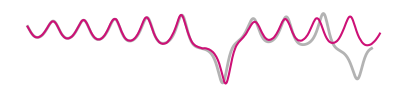

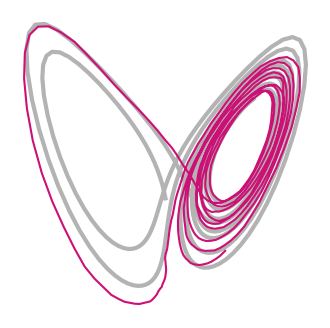

In [33]:
import degas as dg
plt.figure(figsize=(5, 1))
plt.plot(traj_true[:,0], label="True", color=0.7*np.ones(3), linewidth=2)
plt.plot(traj_pred[:,0], label="Pred", color=dg.magenta)
dg.vanish_axes()
# dg.better_savefig("../analysis/fig_resources/panda_univariate.pdf", dpi=300, transparent=True)


plt.figure(figsize=(4, 4))
plt.plot(traj_true[:,0], traj_true[:,2], color=0.7*np.ones(3), linewidth=3)
plt.plot(traj_pred[:,0], traj_pred[:,2], color=dg.magenta)
dg.vanish_axes()
# dg.better_savefig("../analysis/fig_resources/panda_multivariate.pdf", dpi=300, transparent=True)

In [52]:
np.arange(1, traj_context.shape[0], -1)

array([], dtype=int64)

In [62]:
all_panda_pred = list()
for i in range(16, traj_context.shape[0]):
# for i in [traj_context.shape[0], 50]:
    if i % 50 == 0:
        print(f"Processing {i} / {traj_context.shape[0]}")
    traj_context_subset = traj_context[-i:, :].copy()
    context_tensor = torch.tensor(traj_context_subset[None, :], dtype=torch.float32)
    pft_model = PatchTSTPipeline.from_pretrained(
        mode="predict",
        pretrain_path="GilpinLab/panda-72M",
        device_map="mps",
    )
    traj_pred = pft_model.predict(
        context_tensor, 
        len(traj_true), 
        limit_prediction_length=False, 
        sliding_context=True,
    ).squeeze().cpu().numpy()
    all_panda_pred.append(traj_pred)
all_panda_pred = np.array(all_panda_pred)
all_panda_pred.dump("../analysis/fig_resources/all_panda_pred.npy")



Processing 50 / 512
Processing 100 / 512
Processing 150 / 512
Processing 200 / 512
Processing 250 / 512
Processing 300 / 512
Processing 350 / 512
Processing 400 / 512
Processing 450 / 512
Processing 500 / 512


In [63]:
for i, traj_pred in enumerate(all_panda_pred):
    plt.figure(figsize=(4, 4))
    plt.plot(traj_true[:,0], traj_true[:,2], color=0.7*np.ones(3), linewidth=3)
    plt.plot(traj_pred[:,0], traj_pred[:,2], color=dg.magenta)
    plt.xlim(1.1*np.min(traj_true[:,0]), 1.1*np.max(traj_true[:,0]))
    plt.ylim(1.1*np.min(traj_true[:,2]), 1.1*np.max(traj_true[:,2]))
    dg.vanish_axes()
    dg.better_savefig(f"../analysis/fig_resources/panda/panda_multivariate_{str(i).zfill(4)}.png", dpi=300, transparent=True)
    plt.close()

In [130]:
import torch
import sys
# sys.path.append('.')
sys.path.append('./DynaMix/')
from src.model.forecaster import DynaMixForecaster
from src.utilities.utilities import load_hf_model
model = load_hf_model("dynamix-3d-alrnn-v1.0")
model.eval() # Set model to evaluation mode
forecaster = DynaMixForecaster(model) # Initialize the forecaster
## Make DynaMix prediction
context_traj_tensor  = torch.tensor(traj_context)
with torch.no_grad(): 
    reconstruction = forecaster.forecast(
        context=context_traj_tensor,
        horizon=len(traj_true), # Match the horizon of the ground truth
        standardize=True,
    )
# reconstruction = torch.transpose(reconstruction, 0, 1)
traj_pred = reconstruction.detach().numpy()

/Users/william/program_repos/parroting/benchmark/DynaMix/src/model/dynamix.py:95: RuntimeWarning: divide by zero encountered in matmul
  K = R.T @ R / M + np.eye(M)
/Users/william/program_repos/parroting/benchmark/DynaMix/src/model/dynamix.py:95: RuntimeWarning: overflow encountered in matmul
  K = R.T @ R / M + np.eye(M)
/Users/william/program_repos/parroting/benchmark/DynaMix/src/model/dynamix.py:95: RuntimeWarning: invalid value encountered in matmul
  K = R.T @ R / M + np.eye(M)


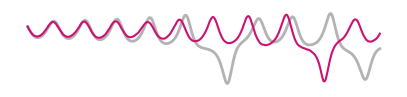

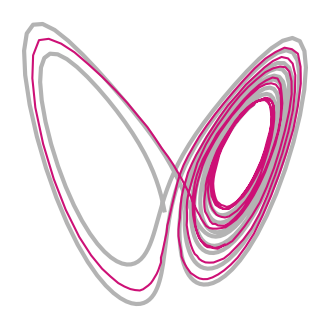

In [131]:
import degas as dg
plt.figure(figsize=(5, 1))
plt.plot(traj_true[:,0], label="True", color=0.7*np.ones(3), linewidth=2)
plt.plot(traj_pred[:,0], label="Pred", color=dg.magenta)
dg.vanish_axes()
dg.better_savefig("../analysis/fig_resources/dynamix_univariate.pdf", dpi=300, transparent=True)


plt.figure(figsize=(4, 4))
plt.plot(traj_true[:,0], traj_true[:,2], color=0.7*np.ones(3), linewidth=3)
plt.plot(traj_pred[:,0], traj_pred[:,2], color=dg.magenta)
dg.vanish_axes()
dg.better_savefig("../analysis/fig_resources/dynamix_multivariate.pdf", dpi=300, transparent=True)